## 对比不同配置（参数量扫描）

想换实验？只换一个组件即可：
- 换模型 -> 改 `build_model('xxx', ...)`
- 换数据 -> 改 `DATASET_PATH`
- 换超参 -> 改 `model_cfg` / `data_cfg`

In [1]:
# experiments = [
#     {'name': 'baseline', 'overrides': {}},
#     {'name': 'deeper', 'overrides': {'n_layer': 12}},
#     {'name': 'wider', 'overrides': {'n_emb': 512}},
#     {'name': 'high_temp', 'overrides': {'attnres_temperature': 4.0}},
# ]

# results = {}
# for exp in experiments:
#     cfg_exp = {**model_cfg, **exp['overrides']}
#     m = build_model('attn_res', **cfg_exp)
#     results[exp['name']] = {
#         'params': count_parameters(m),
#         'config': cfg_exp,
#     }
#     print(f"{exp['name']:12s}: {count_parameters(m)/1e6:.2f}M params, overrides={exp['overrides']}")

# Three Piece Assembly 实验

搭积木式的实验流程：从 `core/` 模块导入组件，组合成实验。

**模块结构：**
- `core.models` - 模型变体（AttnRes, baseline, ...）
- `core.data` - 数据加载
- `core.training` - 训练循环
- `core.eval` - 评估、可视化
- `core.viz` - 模型架构可视化

## 1. 环境准备

In [2]:
import os
os.environ['MUJOCO_GL'] = 'glfw'
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

import sys
from pathlib import Path

REPO_ROOT = Path("/root/mydiffusion")
DIFFUSION_POLICY_ROOT = Path("/root/diffusion_policy")

for p in (REPO_ROOT, DIFFUSION_POLICY_ROOT):
    if p.exists() and str(p) not in sys.path:
        sys.path.insert(0, str(p))

import torch
print(f'Torch {torch.__version__}, CUDA: {torch.cuda.is_available()}')

Torch 2.11.0+cu130, CUDA: True


## 1.5 检查数据集

In [3]:
from pathlib import Path

# 检查数据集是否存在
processed_path = REPO_ROOT / 'data/mimicgen/processed/three_piece_assembly_d0/low_dim_abs.hdf5'
if processed_path.exists():
    print(f"数据集已就绪: {processed_path}")
    print(f"大小: {processed_path.stat().st_size / 1e9:.2f} GB")
else:
    print(f"数据集不存在: {processed_path}")

数据集已就绪: /root/mydiffusion/data/mimicgen/processed/three_piece_assembly_d0/low_dim_abs.hdf5
大小: 3.28 GB


## 2. 配置

In [4]:
DATASET_PATH = REPO_ROOT / 'data/mimicgen/processed/three_piece_assembly_d0/low_dim_abs.hdf5'
OUTPUT_DIR = REPO_ROOT / 'outputs_notebook'
DEVICE = 'cuda:0' if torch.cuda.is_available() else 'cpu'

# ========== 模型配置（根据数据集自动推断） ==========
# 数据集: obs=[16, 51], action=[16, 10]
# obs 的第一维是完整的 horizon=16 timesteps，全部作为 condition
# 注意: model 的 T_cond = 1 (time) + n_obs_steps
#       n_obs_steps 应该等于 horizon，才能匹配 cond 的完整 timesteps

model_cfg = dict(
    input_dim=10,      # action dim
    output_dim=10,     # action dim
    horizon=16,
    n_obs_steps=16,    # 使用完整 horizon 作为 condition（匹配 dataset 输出）
    cond_dim=51,       # obs dim
    n_layer=8,
    n_head=4,
    n_emb=256,
    p_drop_attn=0.3,
    causal_attn=True,
    obs_as_cond=True,
    attnres_last_bias_init=8.0,
    attnres_temperature=2.0,
)

# ========== 数据加载配置（22 核心优化） ==========
# RTX PRO 6000 48GB: batch_size=256-512
data_cfg = dict(
    horizon=16,
    n_obs_steps=16,    # 与 model_cfg.n_obs_steps 保持一致
    n_action_steps=8,
    batch_size=256,
    num_workers=8,
    persistent_workers=True,
    prefetch_factor=4,
    val_ratio=0.02,
)

## 3. 构造模型

In [5]:
from core.models import build_model
from core.eval import count_parameters

model = build_model('attn_res', **model_cfg)
print(f'模型参数量: {count_parameters(model)/1e6:.2f}M')

模型参数量: 8.98M


## 4. 模型可视化（实时查看架构）

改完 `model_cfg` 重跑 cell 3 + 下面 3 个 cell，立刻看到新结构。

- `summary()` - 文本摘要：每层 shape + 参数量
- `draw_model()` - matplotlib 论文风格架构图
- `render_mermaid()` - Mermaid 流程图

In [6]:
from core.viz import summary, draw_model, render_mermaid

sample_shape = (1, model_cfg['horizon'], model_cfg['input_dim'])
cond_shape = (1, model_cfg['n_obs_steps'], model_cfg['cond_dim'])

_ = summary(model, sample_shape=sample_shape, cond_shape=cond_shape)


 Model: ResAttentionTransformerForDiffusion
 sample shape: (1, 16, 10)  |  cond shape: (1, 16, 51)
Module                                                 Output       Params
--------------------------------------------------------------------------
  input_emb                                    (10,) → (256,)        2,816
  cond_obs_emb                                 (51,) → (256,)       13,312
  encoder.0                                  (256,) → (1024,)      263,168
  encoder.2                                  (1024,) → (256,)      262,400
  decoder.layers.0.self_attn.out_proj         (256,) → (256,)       65,792
  decoder.layers.0.cross_attn.out_proj        (256,) → (256,)       65,792
  decoder.layers.0.linear1                   (256,) → (1024,)      263,168
  decoder.layers.0.linear2                   (1024,) → (256,)      262,400
  decoder.layers.0.norm1                            ((256,),)          512
  decoder.layers.0.norm2                            ((256,),)          512


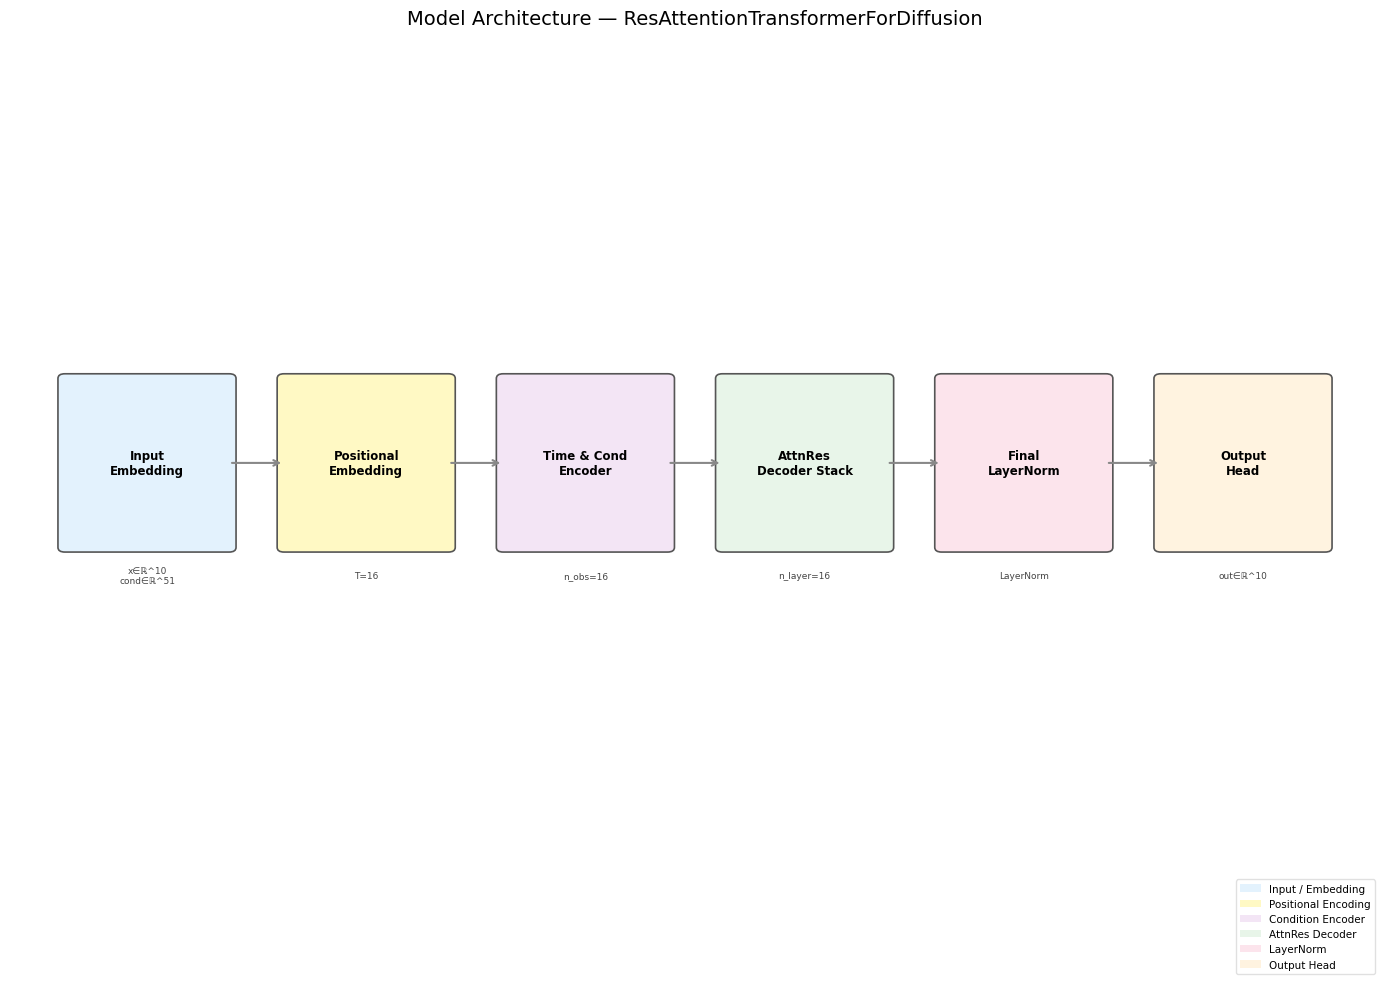

In [7]:
draw_model(model, sample_shape=sample_shape, cond_shape=cond_shape)

In [8]:
# render_mermaid(model)

## 5. 探索数据集

In [9]:
from core.data import inspect_dataset

info = inspect_dataset(DATASET_PATH)
print(f"Episodes: {info['n_episodes']}")
print(f"Avg length: {info['avg_length']:.0f}, max: {info['max_length']}, min: {info['min_length']}")
print(f"Action shape: {info['action_shape']}")
print(f"Obs shapes:")
for k, s in info['obs_shapes'].items():
    print(f'  {k}: {s}')

Episodes: 0
Avg length: 0, max: 0, min: 0
Action shape: ('<unknown>',)
Obs shapes:


## 6. 搭积木：组装训练器

In [10]:
from core.data import load_mimicgen_lowdim
from core.training import DiffusionTrainer, TrainingConfig
from core.eval import plot_history

dataset, train_loader, val_loader = load_mimicgen_lowdim(
    dataset_path=DATASET_PATH,
    **data_cfg,
)
print(f'训练集: {len(dataset)} 条, 验证集: {len(val_loader.dataset)} 条')

# ========== 训练配置（RTX PRO 6000 优化） ==========
cfg = TrainingConfig(
    device=DEVICE,
    num_epochs=5000,
    lr=1e-4,
    weight_decay=1e-3,
    betas=(0.9, 0.95),

    # === RTX PRO 6000 性能优化 ===
    amp_dtype='tf32',           # RTX 30系/A100/RTX PRO 6000 用 TF32（自动）
    cudnn_benchmark=True,       # 自动选最优 cuDNN kernel
    cudnn_deterministic=False, # 速度优先

    # Batch size（RTX PRO 6000 48GB 可用 512-1024）
    batch_size=data_cfg['batch_size'],
    grad_accum_steps=1,         # 显存不够用 2x + grad_accum

    # EMA（稳定收敛）
    use_ema=True,
    ema_decay=0.999,

    # 梯度裁剪
    grad_clip=1.0,

    # 记录
    log_every=10,
    val_every=1,
    checkpoint_every=50,
    output_dir=OUTPUT_DIR,
)

print(f'预估每 epoch: {len(train_loader)} steps, '
      f'effective_batch={cfg.batch_size * cfg.grad_accum_steps}')

trainer = DiffusionTrainer(model, train_loader, val_loader, cfg)

Loading hdf5 to ReplayBuffer: 100%|██████████| 1000/1000 [00:02<00:00, 484.63it/s]


训练集: 343695 条, 验证集: 6873 条
预估每 epoch: 1316 steps, effective_batch=256


## 7. 开始训练

In [11]:
# 正式训练用 num_epochs=5000，这里用 10 做快速测试
history = trainer.fit(num_epochs=2)

Training:   0%|          | 0/2 [00:50<?, ?epoch/s, train_loss=0.1339, lr=1.00e-04, step=1316]

epoch    0  train_loss=0.133878  lr=1.00e-04  step=1316


Training:  50%|█████     | 1/2 [00:51<00:51, 51.10s/epoch, train_loss=0.1339, lr=1.00e-04, step=1316]

  val_loss=0.053561  val_loss_ema=0.198822


Training: 100%|██████████| 2/2 [01:41<00:00, 50.87s/epoch, train_loss=0.0936, lr=1.00e-04, step=2632]

  val_loss=0.045936  val_loss_ema=0.082251


## 7.5 开启 Rollout 评估（写入 `test/mean_score`）

`trainer.fit` 只做监督训练，不会自动跑仿真 rollout。

下面这个 cell 会调用 `scripts/training/train_resattention_mimicgen.py`，
按 `rollout_every` 周期执行 rollout 评估并写入 `logs.json.txt`，
这样后面的任务打分图（`test/mean_score`）就会有数据。

In [ ]:
import subprocess
import sys

# ===== 可调参数 =====
ROLLOUT_EVERY = 10         # 每 N epoch 跑一次 rollout（想更密可以改小）
CHECKPOINT_EVERY = 10
SEED = 42
TASK = 'three_piece_assembly_d0_lowdim_abs'
DEVICE = DEVICE            # 复用上面配置的设备，如 'cuda:0'
RECORD_VIDEO = False       # True 会额外写 mp4 到 media/

cmd = [
    sys.executable,
    str(REPO_ROOT / 'scripts' / 'training' / 'train_resattention_mimicgen.py'),
    '--task', TASK,
    '--seed', str(SEED),
    '--device', DEVICE,
    '--rollout-every', str(ROLLOUT_EVERY),
    '--checkpoint-every', str(CHECKPOINT_EVERY),
]
if RECORD_VIDEO:
    cmd.append('--record-video')

print('Launching rollout-eval training:')
print(' '.join(cmd))
subprocess.run(cmd, check=True, cwd=str(REPO_ROOT))

print('\n✅ 训练完成。现在可运行后面的「训练结果可视化」cell 查看 test/mean_score。')

Launching rollout-eval training:
/root/miniconda3/envs/mujoco/bin/python /root/mydiffusion/scripts/training/train_resattention_mimicgen.py --task three_piece_assembly_d0_lowdim_abs --seed 42 --device cuda:0 --rollout-every 10 --checkpoint-every 10
Got error: No module named 'robosuite_task_zoo'
[2026-05-08 22:26:24,874][resattention_transformer_for_diffusion][INFO] - number of parameters: 8.981290e+06


Loading hdf5 to ReplayBuffer: 100%|██████████| 1000/1000 [00:02<00:00, 495.84it/s]
Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


Created environment with name ThreePieceAssembly_D0
Action size is 7


wandb: WARNING `resume` will be ignored since W&B syncing is set to `offline`. Starting a new run with run id 1vm1zjex.
wandb: Tracking run with wandb version 0.26.1
wandb: W&B syncing is set to `offline` in this directory. Run `wandb online` or set WANDB_MODE=online to enable cloud syncing.
wandb: Run data is saved locally in /root/mydiffusion/outputs_resattention/three-piece-assembly-d0_seed42/wandb/offline-run-20260508_222628-1vm1zjex
Training epoch 4:  70%|███████   | 888/1262 [00:33<00:14, 26.65it/s, loss=0.0491]       

## 10. 加载已有训练日志（用于复盘）

In [ ]:
from core.eval import load_wandb_logs, plot_curves

log_dir = REPO_ROOT / 'outputs/three_piece_assembly_d0_lowdim_abs/42'
records = load_wandb_logs(log_dir)
print(f'加载了 {len(records)} 条记录')

if records:
    plot_curves(records, keys=['train_loss', 'test_mean_score'])

## 11. 训练结果可视化（多指标）

直接读 `train.py` / `train_resattention_mimicgen.py` 写出来的 `outputs/<task>/<seed>/logs.json.txt`，
按"上次重跑"自动切到最后一段 session，分面板画：
- `train_loss / val_loss`
- `train_action_mse_error`
- 学习率 `lr`
- `train/mean_score`、`test/mean_score`（rollout 成功率）
- 每个 seed 的 `train/sim_max_reward_*`、`test/sim_max_reward_*`（自动检测）

> 不依赖 `core/` 模块，仅用 `_runtime.read_json_lines` 和 matplotlib。

In [ ]:
import sys
from pathlib import Path

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
from _runtime import read_json_lines

# ========= 选择一次 run（按需修改） =========
# 普通 baseline (train.py + run_baseline.py)
RUN_DIR = REPO_ROOT / 'outputs_notebook'

# 自动 fallback 到 ResAttention 训练目录
if not (RUN_DIR / 'logs.json.txt').is_file():
    res_root = REPO_ROOT / 'outputs_resattention'
    candidates = sorted(res_root.glob('*')) if res_root.is_dir() else []
    for c in candidates:
        if (c / 'logs.json.txt').is_file():
            RUN_DIR = c
            break

log_path = RUN_DIR / 'logs.json.txt'
print(f'RUN_DIR : {RUN_DIR}')
print(f'log_path: {log_path}  exists={log_path.is_file()}')

assert log_path.is_file(), (
    f'找不到 {log_path}。\n'
    '  - 训练还没开始，或者输出目录不在这里？\n'
    '  - 用 `find outputs* -name logs.json.txt` 看一下，把上面 RUN_DIR 指过去。'
)

records = read_json_lines(log_path)
print(f'共 {len(records)} 条 metric 记录')


def _split_sessions(rs):
    """按 epoch 重置（从 >0 跳回 0）切分；只看最后一段 session。"""
    sessions, cur, prev = [], [], None
    for r in rs:
        if cur and r.get('epoch') == 0 and prev is not None and prev > 0:
            sessions.append(cur)
            cur = []
        cur.append(r)
        prev = r.get('epoch')
    if cur:
        sessions.append(cur)
    return sessions


sessions = _split_sessions(records)
session = sessions[-1]
print(
    f'session 数: {len(sessions)} ｜ 最后一段: '
    f'epoch [{min(r["epoch"] for r in session)}, {max(r["epoch"] for r in session)}], '
    f'step [{min(r["step"] for r in session)}, {max(r["step"] for r in session)}]'
)

In [ ]:
import matplotlib.pyplot as plt
from matplotlib import ticker


def _series(sess, key):
    xs, ys = [], []
    for r in sess:
        if key in r and r[key] is not None:
            xs.append(r['step'])
            ys.append(r[key])
    return xs, ys


sim_train_keys = sorted({k for r in session for k in r if k.startswith('train/sim_max_reward_')})
sim_test_keys = sorted({k for r in session for k in r if k.startswith('test/sim_max_reward_')})

panels = [
    ('Loss',                       [('train_loss', 'train'), ('val_loss', 'val')]),
    ('Action MSE',                 [('train_action_mse_error', 'train_action_mse_error')]),
    ('Learning rate',              [('lr', 'lr')]),
    ('Mean rollout score',         [('train/mean_score', 'train'), ('test/mean_score', 'test')]),
    ('Per-seed sim_max_reward (test)',  [(k, k.rsplit('_', 1)[-1]) for k in sim_test_keys]),
    ('Per-seed sim_max_reward (train)', [(k, k.rsplit('_', 1)[-1]) for k in sim_train_keys]),
]
panels = [p for p in panels if any(_series(session, k)[0] for k, _ in p[1])]

ncols = 2
nrows = (len(panels) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(7.0 * ncols, 3.2 * nrows), squeeze=False)
flat_axes = axes.flatten()

for ax, (title, series) in zip(flat_axes, panels):
    drew = False
    for key, label in series:
        xs, ys = _series(session, key)
        if xs:
            ax.plot(xs, ys, label=label, linewidth=1.1)
            drew = True
    if not drew:
        ax.set_axis_off()
        continue
    ax.set_title(title)
    ax.set_xlabel('step')
    ax.grid(alpha=0.25)
    if len(series) > 1:
        ax.legend(fontsize=8, loc='best')
    if title == 'Learning rate':
        sf = ticker.ScalarFormatter(useMathText=True)
        sf.set_powerlimits((-8, -8))
        sf.set_useOffset(True)
        ax.yaxis.set_major_formatter(sf)
        ax.tick_params(axis='y', labelsize=9)

for ax in flat_axes[len(panels):]:
    ax.set_axis_off()

fig.suptitle(f'{RUN_DIR.name} — last session', fontsize=11)
fig.tight_layout()
plt.show()

best_test = max((r.get('test/mean_score', float('-inf')) for r in session), default=None)
final_train = next((r['train_loss'] for r in reversed(session) if 'train_loss' in r), None)
final_val   = next((r['val_loss']   for r in reversed(session) if 'val_loss'   in r), None)
print(f'best test/mean_score = {best_test}')
print(f'final train_loss     = {final_train}')
print(f'final val_loss       = {final_val}')

# === 人类可读任务打分图（仅展示，不参与训练） ===
test_xs, test_ys = _series(session, 'test/mean_score')
if test_xs:
    best_idx = max(range(len(test_ys)), key=lambda i: test_ys[i])
    best_step, best_score = test_xs[best_idx], test_ys[best_idx]
    final_step, final_score = test_xs[-1], test_ys[-1]

    # 成功率语义映射为 0-100 的展示分
    score_100 = max(0.0, min(100.0, final_score * 100.0))

    fig, ax = plt.subplots(1, 1, figsize=(7.2, 3.8))
    ax.plot(test_xs, test_ys, label='test/mean_score', linewidth=1.2)
    ax.scatter([best_step], [best_score], marker='*', s=140, label=f'best={best_score:.4f}')
    ax.scatter([final_step], [final_score], marker='o', s=50, label=f'final={final_score:.4f}')
    ax.set_title('Task Score (human-readable)')
    ax.set_xlabel('step')
    ax.set_ylabel('test/mean_score')
    ax.grid(alpha=0.25)
    ax.legend(fontsize=8, loc='best')
    fig.tight_layout()
    plt.show()

    print(f'Human-readable score (0-100): {score_100:.2f}')
else:
    print('⚠️ 当前日志没有 test/mean_score，无法绘制任务打分图。')
    print('   需要开启 rollout 评估后才会产生该字段（例如设置 rollout_every）。')

## 12. 仿真视频回放

训练时如果开了 `--record-video`（或 task yaml 里 `n_test_vis>0`），
`RobomimicLowdimRunner` 会把仿真 rollout 写到 `outputs/<task>/<seed>/media/*.mp4`。
这里直接列出来嵌入到 notebook 里看。

> 没视频？看下面那个 cell 的提示，按需重跑一次带 `--record-video` 的训练，
> 或者临时把 `task.env_runner.n_test_vis` 调大跑一次纯评估。

In [ ]:
media_dir = RUN_DIR / 'media'
print(f'media_dir: {media_dir}  exists={media_dir.is_dir()}')

mp4s = sorted(media_dir.glob('*.mp4')) if media_dir.is_dir() else []
print(f'找到 {len(mp4s)} 个视频:')
for m in mp4s:
    size_kib = m.stat().st_size / 1024
    print(f'  - {m.name}  ({size_kib:7.1f} KiB)')

if not mp4s:
    print(
        '\n⚠️ 没找到视频。\n'
        '原因 1: 训练时没开 --record-video（默认会强制 n_train_vis=0、n_test_vis=0）。\n'
        '原因 2: 训练还没跑到第一次 rollout（看 training.rollout_every）。\n'
        '\n解决:\n'
        '  python scripts/training/train_resattention_mimicgen.py \\\n'
        '      --task three_piece_assembly_d0_lowdim_abs --seed 42 \\\n'
        '      --record-video --rollout-every 50\n'
        '\n或者只看 test 视频：临时调大 task.env_runner.n_test_vis 重跑一次评估。'
    )

In [ ]:
from IPython.display import Video, display, Markdown

MAX_VIDEOS = 4
EMBED_BASE64 = True

if mp4s:
    for m in mp4s[:MAX_VIDEOS]:
        display(Markdown(f'**{m.name}**  ·  `{m.relative_to(REPO_ROOT)}`'))
        try:
            display(Video(str(m), embed=EMBED_BASE64))
        except Exception as exc:
            print(f'  ! 无法嵌入 {m.name}: {exc}; 改用相对路径引用')
            display(Video(str(m), embed=False))
    if len(mp4s) > MAX_VIDEOS:
        print(f'... 省略 {len(mp4s) - MAX_VIDEOS} 个视频，调大 MAX_VIDEOS 即可全部展示。')
else:
    print('（无视频可展示，按上一 cell 的提示先把视频跑出来）')